<a href="https://colab.research.google.com/github/chavasvyshnavichowdary-star/BRIDGE-LOAD-DISTRIBUTION-CALCULATOR-/blob/main/Bridge_Load_Distribution_Calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

print("=" * 70)
print("          BRIDGE LOAD DISTRIBUTION CALCULATOR")
print("                    Matrix Method AX = B")
print("=" * 70)

print("""
OBJECTIVE
---------
Calculate the reaction forces at three bridge supports.

Then move a truck load to a different position and observe
how the three support reactions change.

MATHEMATICAL CONCEPTS
---------------------
1. Linear simultaneous equations
2. Matrix representation AX = B
3. Determinant
4. Matrix inverse
5. Unique solution
6. Numerical linear algebra

REAL-WORLD APPLICATION
----------------------
Structural engineering and load distribution in bridges.
""")

          BRIDGE LOAD DISTRIBUTION CALCULATOR
                    Matrix Method AX = B

OBJECTIVE
---------
Calculate the reaction forces at three bridge supports.

Then move a truck load to a different position and observe
how the three support reactions change.

MATHEMATICAL CONCEPTS
---------------------
1. Linear simultaneous equations
2. Matrix representation AX = B
3. Determinant
4. Matrix inverse
5. Unique solution
6. Numerical linear algebra

REAL-WORLD APPLICATION
----------------------
Structural engineering and load distribution in bridges.



In [ ]:

print("""
IMPORTANT MODELING ASSUMPTION
-----------------------------

A bridge supported at three points has three unknown vertical
reaction forces:

    R1, R2, R3

For a rigid body, ordinary equilibrium gives only two
independent equations:

    Sum of vertical forces = 0
    Sum of moments = 0

Therefore, a third equation is required.

We assume:

    • The bridge deck behaves as a rigid beam.
    • Each support behaves like a vertical linear spring.
    • Each support has a known stiffness k.
    • Support deflection is related to reaction by

          delta = R / k

For a rigid deck, the three support deflections lie on one
straight line. This provides the third compatibility equation.

Therefore, the system has three equations and three unknowns.
""")


IMPORTANT MODELING ASSUMPTION
-----------------------------

A bridge supported at three points has three unknown vertical
reaction forces:

    R1, R2, R3

For a rigid body, ordinary equilibrium gives only two
independent equations:

    Sum of vertical forces = 0
    Sum of moments = 0

Therefore, a third equation is required.

We assume:

    • The bridge deck behaves as a rigid beam.
    • Each support behaves like a vertical linear spring.
    • Each support has a known stiffness k.
    • Support deflection is related to reaction by

          delta = R / k

For a rigid deck, the three support deflections lie on one
straight line. This provides the third compatibility equation.

Therefore, the system has three equations and three unknowns.



In [ ]:

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Improve NumPy numerical display
np.set_printoptions(
    precision=4,
    suppress=True
)

print("NumPy version:", np.__version__)
print("Libraries imported successfully.")

NumPy version: 2.1.3
Libraries imported successfully.


In [ ]:


support_positions = np.array([
    0.0,      # Support A
    5.0,      # Support B
    10.0      # Support C
])


# ------------------------------------------------------------
# SUPPORT STIFFNESS
# ------------------------------------------------------------

# Vertical stiffness of each support
# Unit: kN/m

support_stiffness = np.array([
    1000.0,   # Support A
    1000.0,   # Support B
    1000.0    # Support C
])


# ------------------------------------------------------------
# FIXED LOADS
# ------------------------------------------------------------

# Two fixed loads remain in the same position
fixed_load_positions = np.array([
    2.0,
    8.0
])

fixed_load_magnitudes = np.array([
    100.0,
    100.0
])


# ------------------------------------------------------------
# TRUCK LOAD
# ------------------------------------------------------------

truck_load = 150.0       # kN

# Truck position before moving
truck_position_before = 4.0

# Truck position after moving
truck_position_after = 7.0


# ============================================================
# INPUT VALIDATION
# ============================================================

assert len(support_positions) == 3, \
    "Exactly 3 supports are required."

assert len(support_stiffness) == 3, \
    "Exactly 3 stiffness values are required."

assert len(fixed_load_positions) == len(fixed_load_magnitudes), \
    "Every load needs a position and magnitude."

assert np.all(support_stiffness > 0), \
    "Support stiffness must be positive."

assert np.all(np.diff(support_positions) > 0), \
    "Support positions must be increasing."

print("INPUT DATA")
print("-" * 50)

print("Support positions:")
for name, position in zip(
    ["A", "B", "C"],
    support_positions
):
    print(f"  Support {name}: {position:.2f} m")

print("\nSupport stiffness:")
for name, stiffness in zip(
    ["A", "B", "C"],
    support_stiffness
):
    print(f"  Support {name}: {stiffness:.2f} kN/m")

print("\nFixed loads:")
for position, load in zip(
    fixed_load_positions,
    fixed_load_magnitudes
):
    print(
        f"  {load:.2f} kN at {position:.2f} m"
    )

print(f"\nTruck load: {truck_load:.2f} kN")
print(
    f"Truck before: {truck_position_before:.2f} m"
)
print(
    f"Truck after : {truck_position_after:.2f} m"
)

INPUT DATA
--------------------------------------------------
Support positions:
  Support A: 0.00 m
  Support B: 5.00 m
  Support C: 10.00 m

Support stiffness:
  Support A: 1000.00 kN/m
  Support B: 1000.00 kN/m
  Support C: 1000.00 kN/m

Fixed loads:
  100.00 kN at 2.00 m
  100.00 kN at 8.00 m

Truck load: 150.00 kN
Truck before: 4.00 m
Truck after : 7.00 m


In [ ]:

def create_load_case(truck_position):
    """
    Combine the fixed bridge loads with the truck load.

    Returns:
        positions  -> load positions
        magnitudes -> load magnitudes
    """

    positions = np.append(
        fixed_load_positions,
        truck_position
    )

    magnitudes = np.append(
        fixed_load_magnitudes,
        truck_load
    )

    return positions, magnitudes


# Load case 1: truck before movement
positions_before, loads_before = create_load_case(
    truck_position_before
)


# Load case 2: truck after movement
positions_after, loads_after = create_load_case(
    truck_position_after
)


print("LOAD CASE 1")
print("-" * 40)

for x, p in zip(
    positions_before,
    loads_before
):
    print(f"{p:.2f} kN at x = {x:.2f} m")


print("\nLOAD CASE 2")
print("-" * 40)

for x, p in zip(
    positions_after,
    loads_after
):
    print(f"{p:.2f} kN at x = {x:.2f} m")

LOAD CASE 1
----------------------------------------
100.00 kN at x = 2.00 m
100.00 kN at x = 8.00 m
150.00 kN at x = 4.00 m

LOAD CASE 2
----------------------------------------
100.00 kN at x = 2.00 m
100.00 kN at x = 8.00 m
150.00 kN at x = 7.00 m


In [ ]:

def build_matrix(
    support_positions,
    support_stiffness
):
    """
    Construct coefficient matrix A.

    Equation 1:
        R_A + R_B + R_C = total load

    Equation 2:
        x_A R_A + x_B R_B + x_C R_C = total moment

    Equation 3:
        Rigid-deck compatibility
    """

    xA, xB, xC = support_positions

    kA, kB, kC = support_stiffness

    A = np.array([

        # Force equilibrium
        [
            1,
            1,
            1
        ],

        # Moment equilibrium
        [
            xA,
            xB,
            xC
        ],

        # Compatibility
        [
            (xC - xB) / kA,
            -(xC - xA) / kB,
            (xB - xA) / kC
        ]
    ], dtype=float)

    return A


A = build_matrix(
    support_positions,
    support_stiffness
)


print("MATRIX A")
print("=" * 40)
print(A)

MATRIX A
[[ 1.     1.     1.   ]
 [ 0.     5.    10.   ]
 [ 0.005 -0.01   0.005]]


In [ ]:

def build_B(
    load_positions,
    load_magnitudes
):
    """
    Construct the B vector.

    B[0] = total applied vertical load

    B[1] = total applied moment

    B[2] = 0 because compatibility is homogeneous
    """

    total_load = np.sum(
        load_magnitudes
    )

    total_moment = np.sum(
        load_positions * load_magnitudes
    )

    B = np.array([
        total_load,
        total_moment,
        0.0
    ])

    return B


B_before = build_B(
    positions_before,
    loads_before
)

B_after = build_B(
    positions_after,
    loads_after
)


print("B BEFORE truck movement:")
print(B_before)

print("\nB AFTER truck movement:")
print(B_after)

B BEFORE truck movement:
[ 350. 1600.    0.]

B AFTER truck movement:
[ 350. 2050.    0.]


In [ ]:

print("=" * 70)
print("MATRIX EQUATION")
print("=" * 70)

print("""
        A X = B

where

        X = [R_A, R_B, R_C]^T
""")

print("A =")
print(A)

print("\nX =")
print("""
[R_A]
[R_B]
[R_C]
""")

print("B BEFORE =")
print(B_before)

print("\nB AFTER =")
print(B_after)

MATRIX EQUATION

        A X = B

where

        X = [R_A, R_B, R_C]^T

A =
[[ 1.     1.     1.   ]
 [ 0.     5.    10.   ]
 [ 0.005 -0.01   0.005]]

X =

[R_A]
[R_B]
[R_C]

B BEFORE =
[ 350. 1600.    0.]

B AFTER =
[ 350. 2050.    0.]


In [ ]:

det_A = np.linalg.det(A)

print("=" * 60)
print("UNIQUE SOLUTION CHECK")
print("=" * 60)

print(f"det(A) = {det_A:.8f}")

if abs(det_A) < 1e-12:
    print("\nA is singular.")
    print("A unique solution does NOT exist.")
    raise ValueError(
        "Matrix A is singular."
    )

else:
    print("\nA is non-singular.")
    print("det(A) != 0")
    print("Therefore A is invertible.")
    print("Therefore AX = B has a UNIQUE solution.")

UNIQUE SOLUTION CHECK
det(A) = 0.15000000

A is non-singular.
det(A) != 0
Therefore A is invertible.
Therefore AX = B has a UNIQUE solution.


In [ ]:

A_inverse = np.linalg.inv(A)

print("MATRIX INVERSE A^(-1)")
print("=" * 50)

print(A_inverse)


# ------------------------------------------------------------
# Verify A^(-1) A = I
# ------------------------------------------------------------

identity = A_inverse @ A

print("\nA^(-1) A =")
print(identity)


print("\nIs this approximately the identity matrix?")

print(
    np.allclose(
        identity,
        np.eye(3)
    )
)

MATRIX INVERSE A^(-1)
[[  0.8333  -0.1     33.3333]
 [  0.3333   0.     -66.6667]
 [ -0.1667   0.1     33.3333]]

A^(-1) A =
[[ 1. -0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

Is this approximately the identity matrix?
True


In [ ]:


def solve_system(A, B):
    """
    Solve:

        AX = B

    using the matrix inverse:

        X = A^(-1)B

    Also calculate the solution using NumPy's
    linear solver for verification.
    """

    A_inverse = np.linalg.inv(A)

    # Required mathematical method
    X_inverse = A_inverse @ B

    # Numerically preferred method
    X_solve = np.linalg.solve(A, B)

    return X_inverse, X_solve


# ------------------------------------------------------------
# BEFORE
# ------------------------------------------------------------

reaction_before_inverse, reaction_before = solve_system(
    A,
    B_before
)


# ------------------------------------------------------------
# AFTER
# ------------------------------------------------------------

reaction_after_inverse, reaction_after = solve_system(
    A,
    B_after
)


print("REACTIONS BEFORE TRUCK MOVEMENT")
print("=" * 50)

for name, reaction in zip(
    ["R_A", "R_B", "R_C"],
    reaction_before
):
    print(
        f"{name} = {reaction:.4f} kN"
    )


print("\nREACTIONS AFTER TRUCK MOVEMENT")
print("=" * 50)

for name, reaction in zip(
    ["R_A", "R_B", "R_C"],
    reaction_after
):
    print(
        f"{name} = {reaction:.4f} kN"
    )


# Verify both solution techniques
print("\nInverse method verification:")

print(
    "Before:",
    np.allclose(
        reaction_before_inverse,
        reaction_before
    )
)

print(
    "After :",
    np.allclose(
        reaction_after_inverse,
        reaction_after
    )
)

REACTIONS BEFORE TRUCK MOVEMENT
R_A = 131.6667 kN
R_B = 116.6667 kN
R_C = 101.6667 kN

REACTIONS AFTER TRUCK MOVEMENT
R_A = 86.6667 kN
R_B = 116.6667 kN
R_C = 146.6667 kN

Inverse method verification:
Before: True
After : True


In [ ]:

A_sym = sp.Matrix(A)

B_before_sym = sp.Matrix(B_before)

B_after_sym = sp.Matrix(B_after)


print("A using SymPy:")
sp.pprint(A_sym)


print("\nA^(-1) using SymPy:")
sp.pprint(A_sym.inv())


print("\nSolution BEFORE movement:")
sp.pprint(
    A_sym.inv() * B_before_sym
)


print("\nSolution AFTER movement:")
sp.pprint(
    A_sym.inv() * B_after_sym
)

A using SymPy:
⎡ 1.0    1.0    1.0 ⎤
⎢                   ⎥
⎢ 0.0    5.0   10.0 ⎥
⎢                   ⎥
⎣0.005  -0.01  0.005⎦

A^(-1) using SymPy:
⎡0.833333333333333   -0.1  33.3333333333333 ⎤
⎢                                           ⎥
⎢0.333333333333333    0    -66.6666666666667⎥
⎢                                           ⎥
⎣-0.166666666666667  0.1   33.3333333333333 ⎦

Solution BEFORE movement:
⎡131.666666666667⎤
⎢                ⎥
⎢116.666666666667⎥
⎢                ⎥
⎣101.666666666667⎦

Solution AFTER movement:
⎡86.6666666666666⎤
⎢                ⎥
⎢116.666666666667⎥
⎢                ⎥
⎣146.666666666667⎦


In [ ]:

change = (
    reaction_after - reaction_before
)

percentage_change = (
    change / reaction_before
) * 100


print("=" * 80)
print("              SUPPORT REACTION RESULTS")
print("=" * 80)

print(
    f"{'Support':<12}"
    f"{'Before (kN)':>18}"
    f"{'After (kN)':>18}"
    f"{'Change (kN)':>18}"
)

print("-" * 80)

for i, name in enumerate(
    ["Support A", "Support B", "Support C"]
):

    print(
        f"{name:<12}"
        f"{reaction_before[i]:>18.2f}"
        f"{reaction_after[i]:>18.2f}"
        f"{change[i]:>18.2f}"
    )

print("-" * 80)

print(
    f"{'TOTAL':<12}"
    f"{np.sum(reaction_before):>18.2f}"
    f"{np.sum(reaction_after):>18.2f}"
    f"{np.sum(change):>18.2f}"
)

              SUPPORT REACTION RESULTS
Support            Before (kN)        After (kN)       Change (kN)
--------------------------------------------------------------------------------
Support A               131.67             86.67            -45.00
Support B               116.67            116.67             -0.00
Support C               101.67            146.67             45.00
--------------------------------------------------------------------------------
TOTAL                   350.00            350.00              0.00


In [ ]:

def verify_solution(
    reactions,
    load_positions,
    load_magnitudes
):

    # --------------------------------------------------------
    # 1. Force equilibrium
    # --------------------------------------------------------

    total_reaction = np.sum(
        reactions
    )

    total_load = np.sum(
        load_magnitudes
    )


    # --------------------------------------------------------
    # 2. Moment equilibrium
    # --------------------------------------------------------

    reaction_moment = np.sum(
        support_positions * reactions
    )

    load_moment = np.sum(
        load_positions * load_magnitudes
    )


    # --------------------------------------------------------
    # 3. Compatibility
    # --------------------------------------------------------

    xA, xB, xC = support_positions

    kA, kB, kC = support_stiffness

    compatibility = (
        (xC - xB) * reactions[0] / kA
        -
        (xC - xA) * reactions[1] / kB
        +
        (xB - xA) * reactions[2] / kC
    )


    print(
        f"Applied load       = {total_load:.6f} kN"
    )

    print(
        f"Support reactions  = {total_reaction:.6f} kN"
    )

    print()

    print(
        f"Applied moment     = {load_moment:.6f} kN.m"
    )

    print(
        f"Reaction moment    = {reaction_moment:.6f} kN.m"
    )

    print()

    print(
        f"Compatibility residual = "
        f"{compatibility:.12f}"
    )

    print("\nCHECKS")

    print(
        "Force equilibrium :",
        np.isclose(
            total_reaction,
            total_load
        )
    )

    print(
        "Moment equilibrium:",
        np.isclose(
            reaction_moment,
            load_moment
        )
    )

    print(
        "Compatibility     :",
        np.isclose(
            compatibility,
            0
        )
    )


print("=" * 70)
print("VERIFICATION BEFORE TRUCK MOVEMENT")
print("=" * 70)

verify_solution(
    reaction_before,
    positions_before,
    loads_before
)


print("\n" + "=" * 70)
print("VERIFICATION AFTER TRUCK MOVEMENT")
print("=" * 70)

verify_solution(
    reaction_after,
    positions_after,
    loads_after
)

VERIFICATION BEFORE TRUCK MOVEMENT
Applied load       = 350.000000 kN
Support reactions  = 350.000000 kN

Applied moment     = 1600.000000 kN.m
Reaction moment    = 1600.000000 kN.m

Compatibility residual = 0.000000000000

CHECKS
Force equilibrium : True
Moment equilibrium: True
Compatibility     : True

VERIFICATION AFTER TRUCK MOVEMENT
Applied load       = 350.000000 kN
Support reactions  = 350.000000 kN

Applied moment     = 2050.000000 kN.m
Reaction moment    = 2050.000000 kN.m

Compatibility residual = 0.000000000000

CHECKS
Force equilibrium : True
Moment equilibrium: True
Compatibility     : True


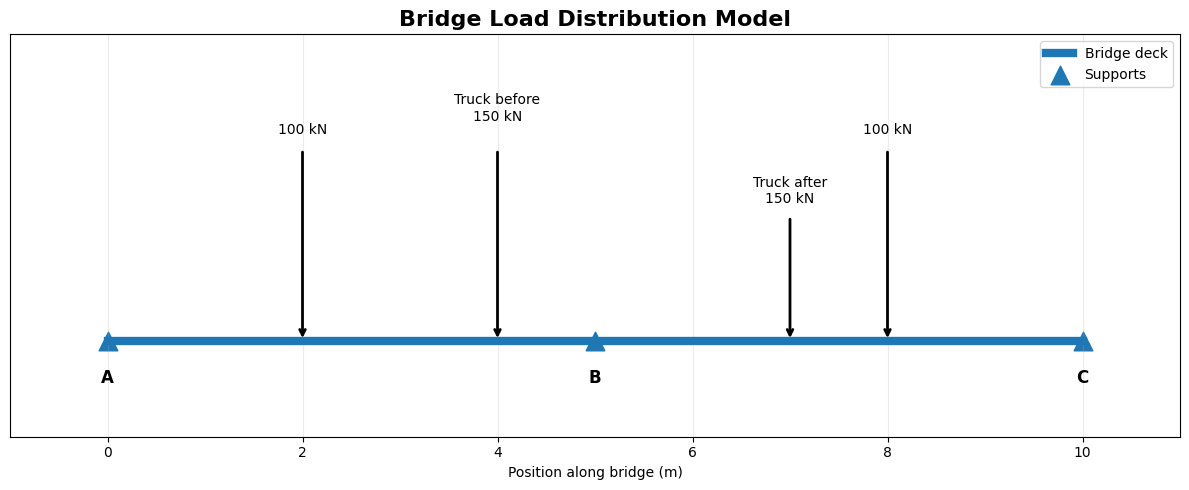

In [ ]:

fig, ax = plt.subplots(
    figsize=(12, 5)
)

# Bridge deck
ax.plot(
    support_positions,
    [0, 0, 0],
    linewidth=6,
    label="Bridge deck"
)

# Supports
ax.scatter(
    support_positions,
    [0, 0, 0],
    s=180,
    marker="^",
    label="Supports"
)


# Support names
for i, x in enumerate(
    support_positions
):

    ax.text(
        x,
        -0.22,
        ["A", "B", "C"][i],
        ha="center",
        fontsize=12,
        fontweight="bold"
    )


# Plot fixed loads
for x, p in zip(
    fixed_load_positions,
    fixed_load_magnitudes
):

    ax.annotate(
        "",
        xy=(x, 0),
        xytext=(x, 1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2
        )
    )

    ax.text(
        x,
        1.08,
        f"{p:.0f} kN",
        ha="center"
    )


# Truck BEFORE
ax.annotate(
    "",
    xy=(truck_position_before, 0),
    xytext=(truck_position_before, 1),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2
    )
)

ax.text(
    truck_position_before,
    1.15,
    f"Truck before\n{truck_load:.0f} kN",
    ha="center"
)


# Truck AFTER
ax.annotate(
    "",
    xy=(truck_position_after, 0),
    xytext=(truck_position_after, 0.65),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2
    )
)

ax.text(
    truck_position_after,
    0.72,
    f"Truck after\n{truck_load:.0f} kN",
    ha="center"
)


ax.set_title(
    "Bridge Load Distribution Model",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Position along bridge (m)"
)

ax.set_yticks([])

ax.set_xlim(
    -1,
    11
)

ax.set_ylim(
    -0.5,
    1.6
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.legend()

plt.tight_layout()
plt.show()

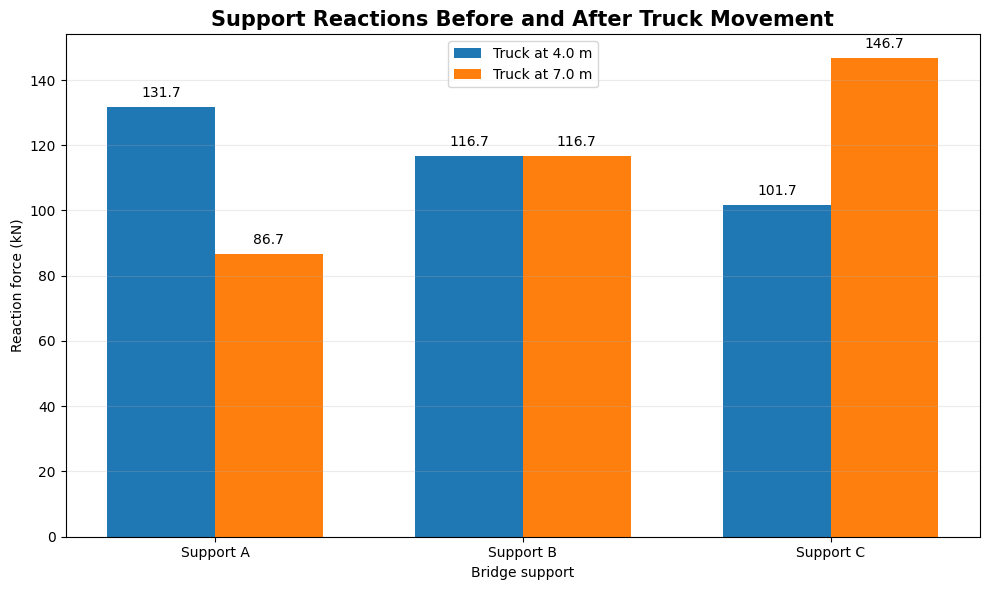

In [ ]:

support_names = [
    "Support A",
    "Support B",
    "Support C"
]

x = np.arange(3)

width = 0.35


fig, ax = plt.subplots(
    figsize=(10, 6)
)


bars1 = ax.bar(
    x - width / 2,
    reaction_before,
    width,
    label=f"Truck at {truck_position_before} m"
)

bars2 = ax.bar(
    x + width / 2,
    reaction_after,
    width,
    label=f"Truck at {truck_position_after} m"
)


# Add values
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 3,
            f"{height:.1f}",
            ha="center",
            fontsize=10
        )


ax.set_title(
    "Support Reactions Before and After Truck Movement",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Bridge support"
)

ax.set_ylabel(
    "Reaction force (kN)"
)

ax.set_xticks(x)

ax.set_xticklabels(
    support_names
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

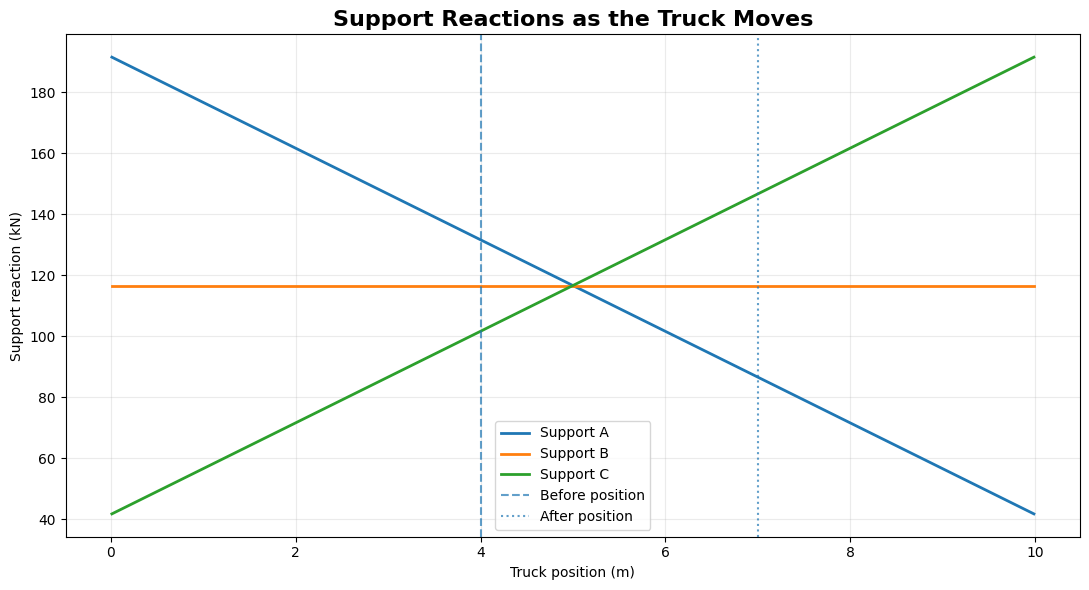

In [ ]:

truck_positions = np.linspace(
    support_positions[0] + 0.01,
    support_positions[-1] - 0.01,
    100
)


reaction_history = []


for truck_x in truck_positions:

    # Create loads
    positions, loads = create_load_case(
        truck_x
    )

    # Construct B
    B = build_B(
        positions,
        loads
    )

    # Solve AX = B
    reactions = np.linalg.solve(
        A,
        B
    )

    reaction_history.append(
        reactions
    )


reaction_history = np.array(
    reaction_history
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)


for i, name in enumerate(
    support_names
):

    ax.plot(
        truck_positions,
        reaction_history[:, i],
        linewidth=2,
        label=name
    )


# Mark original truck positions
ax.axvline(
    truck_position_before,
    linestyle="--",
    alpha=0.7,
    label="Before position"
)

ax.axvline(
    truck_position_after,
    linestyle=":",
    alpha=0.7,
    label="After position"
)


ax.set_title(
    "Support Reactions as the Truck Moves",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Truck position (m)"
)

ax.set_ylabel(
    "Support reaction (kN)"
)

ax.legend()

ax.grid(
    True,
    alpha=0.25
)

plt.tight_layout()
plt.show()

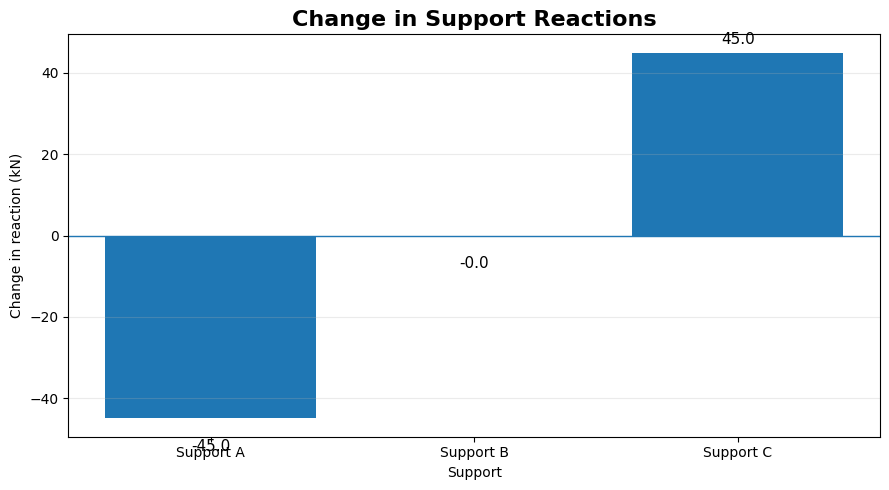

In [ ]:

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars = ax.bar(
    support_names,
    change
)


for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (2 if height >= 0 else -8),
        f"{height:.1f}",
        ha="center",
        fontsize=11
    )


ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Change in Support Reactions",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Support"
)

ax.set_ylabel(
    "Change in reaction (kN)"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [ ]:

print("=" * 75)
print("                    FINAL PROJECT REPORT")
print("=" * 75)

print("\nPROJECT TITLE")
print("Bridge Load Distribution Calculator (A2)")


print("\nMATHEMATICAL MODEL")
print("------------------")
print("AX = B")
print("X = A^(-1)B")


print("\nDETERMINANT")
print("-----------")
print(f"det(A) = {det_A:.6f}")

if abs(det_A) > 1e-12:
    print("Unique solution exists.")


print("\nTRUCK MOVEMENT")
print("--------------")
print(
    f"Before: {truck_position_before:.2f} m"
)
print(
    f"After : {truck_position_after:.2f} m"
)


print("\nSUPPORT REACTIONS")
print("-----------------")

for i, name in enumerate(
    support_names
):

    print(
        f"{name}: "
        f"{reaction_before[i]:.2f} kN"
        f" -> "
        f"{reaction_after[i]:.2f} kN"
    )


print("\nREACTION CHANGES")
print("----------------")

for i, name in enumerate(
    support_names
):

    direction = (
        "increased"
        if change[i] > 0
        else
        "decreased"
        if change[i] < 0
        else
        "did not change"
    )

    print(
        f"{name}: {abs(change[i]):.2f} kN "
        f"{direction}"
    )


print("\nTOTAL LOAD CHECK")
print("----------------")

print(
    f"Total applied load: "
    f"{np.sum(loads_before):.2f} kN"
)

print(
    f"Total reaction before: "
    f"{np.sum(reaction_before):.2f} kN"
)

print(
    f"Total reaction after: "
    f"{np.sum(reaction_after):.2f} kN"
)


print("\nCONCLUSION")
print("----------")
print("""
The matrix method successfully calculates the three support
reactions of the bridge.

When the truck changes position, the right-hand side vector B
changes while the structural matrix A remains unchanged.

Therefore:

        X_before = A^(-1) B_before

and

        X_after = A^(-1) B_after

The experiment demonstrates how a change in an applied load
causes the support reactions to redistribute.

This provides a practical application of matrices and linear
equations in structural engineering.
""")

print("=" * 75)

                    FINAL PROJECT REPORT

PROJECT TITLE
Bridge Load Distribution Calculator (A2)

MATHEMATICAL MODEL
------------------
AX = B
X = A^(-1)B

DETERMINANT
-----------
det(A) = 0.150000
Unique solution exists.

TRUCK MOVEMENT
--------------
Before: 4.00 m
After : 7.00 m

SUPPORT REACTIONS
-----------------
Support A: 131.67 kN -> 86.67 kN
Support B: 116.67 kN -> 116.67 kN
Support C: 101.67 kN -> 146.67 kN

REACTION CHANGES
----------------
Support A: 45.00 kN decreased
Support B: 0.00 kN decreased
Support C: 45.00 kN increased

TOTAL LOAD CHECK
----------------
Total applied load: 350.00 kN
Total reaction before: 350.00 kN
Total reaction after: 350.00 kN

CONCLUSION
----------

The matrix method successfully calculates the three support
reactions of the bridge.

When the truck changes position, the right-hand side vector B
changes while the structural matrix A remains unchanged.

Therefore:

        X_before = A^(-1) B_before

and

        X_after = A^(-1) B_after

The expe